In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 (맑은 고딕)
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'   # 맥 (애플고딕)
else:
    plt.rcParams['font.family'] = 'NanumGothic'    # 리눅스 (나눔고딕)

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

df_reviews = pd.read_csv('steam_indie_reviews.csv')
df_sample = pd.read_csv('steam_stratified_sample.csv')

분석 대상 게임 수: 73개
수집된 초기 90일 리뷰 총합: 13106건


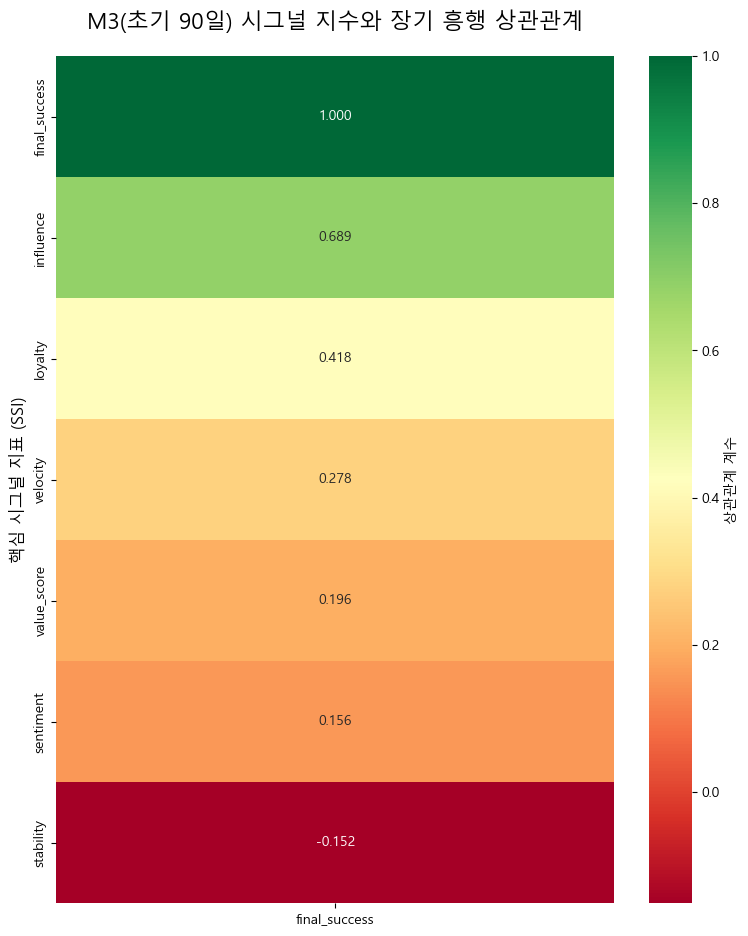

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 로드 및 전처리
df_reviews = pd.read_csv('steam_indie_reviews.csv')
df_sample = pd.read_csv('steam_stratified_sample.csv')

# 컬럼명 정리 및 appid 타입 통일
df_reviews.columns = df_reviews.columns.str.strip()
df_sample.columns = df_sample.columns.str.strip()
df_reviews['appid'] = df_reviews['appid'].astype(str)
df_sample['appid'] = df_sample['appid'].astype(str)

# 2. M3(출시 초기 90일) 데이터 필터링 로직
# timestamp_created(초 단위)를 날짜 객체로 변환
df_reviews['review_date'] = pd.to_datetime(df_reviews['timestamp_created'], unit='s')
df_sample['release_date_dt'] = pd.to_datetime(df_sample['release_date'])

# 분석 대상인 상위 3개 그룹(74개 게임)만 추출
target_strata = ['large_high', 'mid_high', 'small_high']
df_target_games = df_sample[df_sample['stratum'].isin(target_strata)].copy()

# 리뷰 데이터와 게임 메타데이터 병합
df_merged = pd.merge(
    df_reviews, 
    df_target_games[['appid', 'release_date_dt', 'total_reviews', 'price_spy']], 
    on='appid'
)

# 출시일로부터 리뷰 작성일까지의 기간(일) 계산
df_merged['days_since_release'] = (df_merged['review_date'] - df_merged['release_date_dt']).dt.days

# [M3 필터] 출시 후 0일 ~ 90일 사이의 리뷰만 추출
df_m3 = df_merged[(df_merged['days_since_release'] >= 0) & (df_merged['days_since_release'] <= 90)].copy()

print(f"분석 대상 게임 수: {df_m3['appid'].nunique()}개")
print(f"수집된 초기 90일 리뷰 총합: {len(df_m3)}건")

# 3. 5대 핵심 SSI 지표 집계 (유저 선정 지표 기준)
df_m3['voted_up_numeric'] = df_m3['voted_up'].astype(int)

ssi_summary = df_m3.groupby('appid').agg(
    velocity=('voted_up_numeric', 'count'),                # 1. 리뷰 밀도 (양적 기세)
    sentiment=('voted_up_numeric', 'mean'),               # 2. 초기 민심 (제품 질)
    loyalty=('author_playtime_at_review', 'mean'),         # 3. 몰입 깊이 (중독성)
    influence=('weighted_vote_score', 'sum'),              # 4. 리뷰 전파력 (바이럴)
    price_spy=('price_spy', 'first'),                      # 가성비 계산용 가격
    final_success=('total_reviews', 'first')               # 정답지 (최종 흥행 규모)
).reset_index()

# 5. 가성비(Value) 및 안정성(Stability) 추가 계산
# Stability: 90일간 민심의 표준편차 (fillna(0)는 리뷰 1개인 경우 처리)
ssi_summary['stability'] = df_m3.groupby('appid')['voted_up_numeric'].std().values
ssi_summary['stability'] = ssi_summary['stability'].fillna(0)

# Value Score: 1달러당 플레이 시간 (분)
ssi_summary['value_score'] = ssi_summary['loyalty'] / (ssi_summary['price_spy'] / 100)

# 4. 최종 흥행과의 상관관계 분석 (Spearman)
# 최종 흥행(final_success)과 가장 관련 있는 '미래 시그널' 찾기
analysis_cols = ['velocity', 'sentiment', 'loyalty', 'influence', 'stability', 'value_score', 'final_success']
corr_matrix = ssi_summary[analysis_cols].corr(method='spearman')

# 5. 시각화 (보고서용 히트맵)
plt.figure(figsize=(9, 11))
sns.heatmap(corr_matrix[['final_success']].sort_values(by='final_success', ascending=False), 
            annot=True, cmap='RdYlGn', fmt=".3f", cbar_kws={'label': '상관관계 계수'})

plt.title("M3(초기 90일) 시그널 지수와 장기 흥행 상관관계", fontsize=16, pad=20)
plt.ylabel("핵심 시그널 지표 (SSI)", fontsize=12)
plt.show()

In [9]:
# 상관관계 수치만 추출하여 내림차순 정렬
success_corr = corr_matrix[['final_success']].sort_values(by='final_success', ascending=False)

# 보고서용 텍스트 출력
print("\n" + "="*50)
print("   [SSI] 초기 90일 시그널별 흥행 상관계수 (Table)   ")
print("="*50)
print(success_corr)
print("="*50)

# 특정 지표에 대한 코멘트 자동 생성 예시
top_signal = success_corr.index[1] # final_success 제외 1위
top_val = success_corr.iloc[1, 0]
print(f" 가장 강력한 미래 흥행 시그널은 '{top_signal}'(으)로, 수치는 {top_val:.3f}입니다.")


   [SSI] 초기 90일 시그널별 흥행 상관계수 (Table)   
               final_success
final_success       1.000000
influence           0.689246
loyalty             0.417768
velocity            0.277995
value_score         0.195682
sentiment           0.156006
stability          -0.151692
 가장 강력한 미래 흥행 시그널은 'influence'(으)로, 수치는 0.689입니다.


장르별은?

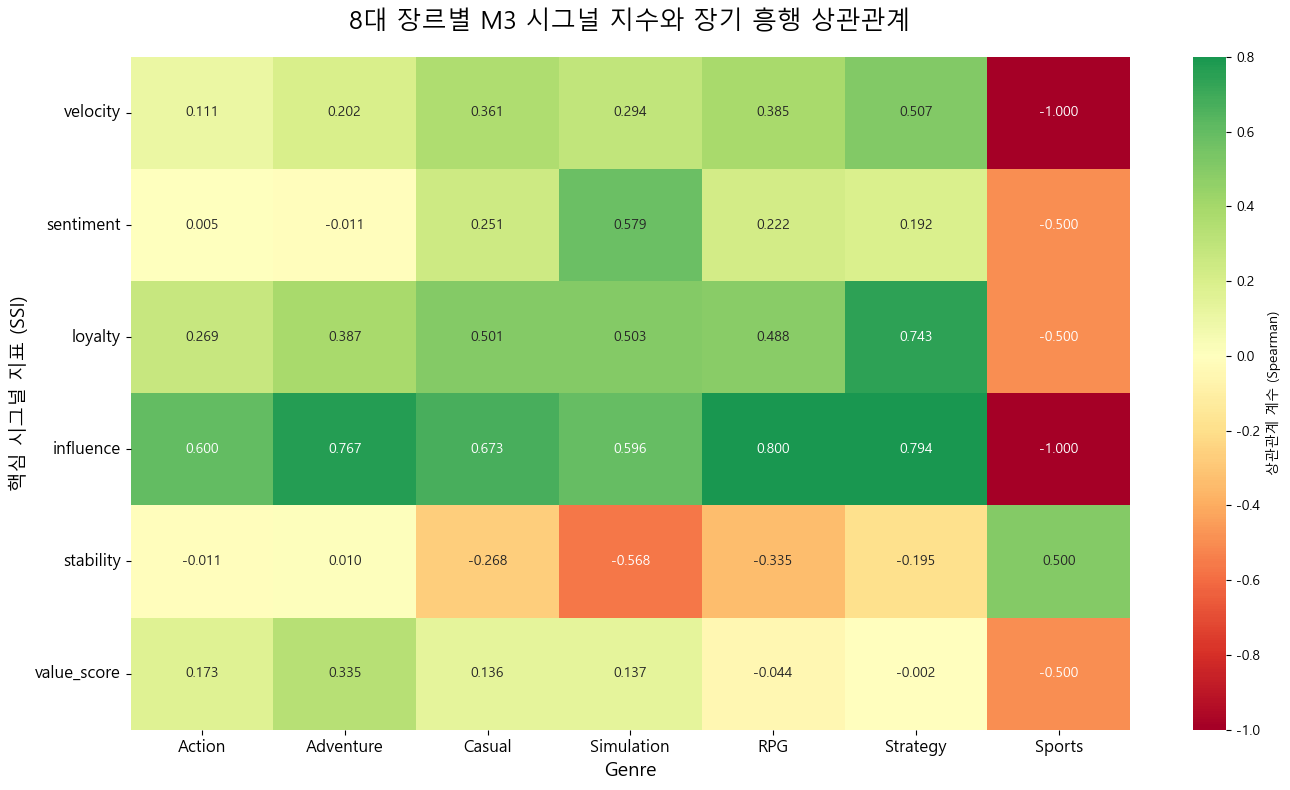

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 폰트 설정 (한글 깨짐 방지용)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 및 초기 90일(M3) 데이터 준비
df_reviews = pd.read_csv('steam_indie_reviews.csv')
df_sample = pd.read_csv('steam_stratified_sample.csv')

# 컬럼명 정리 및 appid 타입 통일
df_reviews.columns = df_reviews.columns.str.strip()
df_sample.columns = df_sample.columns.str.strip()
df_reviews['appid'] = df_reviews['appid'].astype(str)
df_sample['appid'] = df_sample['appid'].astype(str)

# 날짜 변환 및 필터링
df_sample['release_date_dt'] = pd.to_datetime(df_sample['release_date'])
df_reviews['review_date'] = pd.to_datetime(df_reviews['timestamp_created'], unit='s')

df_merged = pd.merge(df_reviews, df_sample[['appid', 'release_date_dt', 'total_reviews', 'price_spy', 'genres']], on='appid')
df_merged['days_since_release'] = (df_merged['review_date'] - df_merged['release_date_dt']).dt.days

df_m3 = df_merged[(df_merged['days_since_release'] >= 0) & (df_merged['days_since_release'] <= 90)].copy()
df_m3['voted_up_numeric'] = df_m3['voted_up'].astype(int)

# 2. 8개 세부 장르 키워드 매핑 (X축 표시 이름을 영어로 변경)
target_genres = {
    'Action': 'Action',
    'Adventure': 'Adventure',
    'Casual': 'Casual',
    'Simulation': 'Simulation',
    'RPG': 'RPG',
    'Strategy': 'Strategy',
    'Sports': 'Sports',
    'Racing': 'Racing'
}

# 각 장르별 상관계수 결과를 모을 딕셔너리
genre_corr_dict = {}
analysis_cols = ['velocity', 'sentiment', 'loyalty', 'influence', 'stability', 'value_score']

# 3. 장르별로 쪼개서 지표 및 상관계수 계산
for genre_name, keyword in target_genres.items():
    genre_df = df_m3[df_m3['genres'].str.contains(keyword, case=False, na=False)]
    
    if genre_df.empty:
        continue
        
    ssi_summary = genre_df.groupby('appid').agg(
        velocity=('voted_up_numeric', 'count'),
        sentiment=('voted_up_numeric', 'mean'),
        loyalty=('author_playtime_at_review', 'mean'),
        influence=('weighted_vote_score', 'sum'),
        price_spy=('price_spy', 'first'),
        final_success=('total_reviews', 'first')
    ).reset_index()
    
    stability_map = genre_df.groupby('appid')['voted_up_numeric'].std().fillna(0)
    ssi_summary['stability'] = ssi_summary['appid'].map(stability_map)
    ssi_summary['value_score'] = ssi_summary['loyalty'] / (ssi_summary['price_spy'] / 100)
    
    # 데이터가 유효한 경우만 상관계수 추출
    if len(ssi_summary) > 2:
        corr_matrix = ssi_summary[analysis_cols + ['final_success']].corr(method='spearman')
        genre_corr_dict[genre_name] = corr_matrix.loc[analysis_cols, 'final_success']

# 4. 히트맵을 위한 2D 데이터프레임 조립 (행: 시그널, 열: 장르)
heatmap_df = pd.DataFrame(genre_corr_dict)

# 5. 시각화
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_df, 
            annot=True, 
            cmap='RdYlGn', 
            fmt=".3f", 
            center=0, 
            cbar_kws={'label': '상관관계 계수 (Spearman)'})

plt.title("8대 장르별 M3 시그널 지수와 장기 흥행 상관관계", fontsize=18, pad=20)
plt.ylabel("핵심 시그널 지표 (SSI)", fontsize=14)
plt.xlabel("Genre", fontsize=14) # X축 라벨도 영어로 통일
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np

# 1. 데이터 로드 및 전처리
df_reviews = pd.read_csv('steam_indie_reviews.csv')
df_sample = pd.read_csv('steam_stratified_sample.csv')

# 컬럼명 정리 및 appid 타입 통일
df_reviews.columns = df_reviews.columns.str.strip()
df_sample.columns = df_sample.columns.str.strip()
df_reviews['appid'] = df_reviews['appid'].astype(str)
df_sample['appid'] = df_sample['appid'].astype(str)

# 2. M3(출시 초기 90일) 데이터 필터링 로직
df_reviews['review_date'] = pd.to_datetime(df_reviews['timestamp_created'], unit='s')
df_sample['release_date_dt'] = pd.to_datetime(df_sample['release_date'])

df_merged = pd.merge(df_reviews, df_sample[['appid', 'release_date_dt', 'total_reviews', 'price_spy', 'genres']], on='appid')
df_merged['days_since_release'] = (df_merged['review_date'] - df_merged['release_date_dt']).dt.days

df_m3 = df_merged[(df_merged['days_since_release'] >= 0) & (df_merged['days_since_release'] <= 90)].copy()
df_m3['voted_up_numeric'] = df_m3['voted_up'].astype(int)

# 3. 8개 세부 장르 매핑 (영문)
target_genres = {
    'Action': 'Action',
    'Adventure': 'Adventure',
    'Casual': 'Casual',
    'Simulation': 'Simulation',
    'RPG': 'RPG',
    'Strategy': 'Strategy',
    'Sports': 'Sports',
    'Racing': 'Racing'
}

analysis_cols = ['velocity', 'sentiment', 'loyalty', 'influence', 'stability', 'value_score']

# 4. 장르별 데이터 추출 및 텍스트 리포트 출력
for genre_name, keyword in target_genres.items():
    genre_df = df_m3[df_m3['genres'].str.contains(keyword, case=False, na=False)]
    
    if genre_df.empty:
        continue
        
    ssi_summary = genre_df.groupby('appid').agg(
        velocity=('voted_up_numeric', 'count'),
        sentiment=('voted_up_numeric', 'mean'),
        loyalty=('author_playtime_at_review', 'mean'),
        influence=('weighted_vote_score', 'sum'),
        price_spy=('price_spy', 'first'),
        final_success=('total_reviews', 'first')
    ).reset_index()
    
    stability_map = genre_df.groupby('appid')['voted_up_numeric'].std().fillna(0)
    ssi_summary['stability'] = ssi_summary['appid'].map(stability_map)
    ssi_summary['value_score'] = ssi_summary['loyalty'] / (ssi_summary['price_spy'] / 100)
    
    if len(ssi_summary) > 2:
        # 상관관계 계산
        corr_matrix = ssi_summary[analysis_cols + ['final_success']].corr(method='spearman')
        
        # [수정 포인트] final_success 자기 자신(1.0)은 제외하고 6개 시그널만 내림차순 정렬
        success_corr = corr_matrix[['final_success']].drop('final_success').sort_values(by='final_success', ascending=False)
        
        # 유저님이 작성하신 텍스트 출력 포맷 적용
        print("\n" + "="*50)
        print(f"   [{genre_name}] 초기 90일 시그널별 흥행 상관계수   ")
        print("="*50)
        print(success_corr.round(3)) # 보기 좋게 소수점 3자리까지만 출력
        print("="*50)

        # 코멘트 자동 생성 (자기 자신을 제외했으므로 1위는 index[0]이 됩니다)
        top_signal = success_corr.index[0]
        top_val = success_corr.iloc[0, 0]
        
        # 수치가 음수이거나 너무 낮을 때의 예외 처리 추가 (옵션)
        if top_val < 0.2:
            print(f" '{genre_name}' 장르에서는 뚜렷한 강력한 흥행 시그널이 발견되지 않았습니다. (최고치: {top_signal}, {top_val:.3f})")
        else:
            print(f" 가장 강력한 미래 흥행 시그널은 '{top_signal}'(으)로, 수치는 {top_val:.3f}입니다.")
            
print("\n✅ 모든 장르의 리포트 출력이 완료되었습니다.")


   [Action] 초기 90일 시그널별 흥행 상관계수   
             final_success
influence            0.600
loyalty              0.269
value_score          0.173
velocity             0.111
sentiment            0.005
stability           -0.011
 가장 강력한 미래 흥행 시그널은 'influence'(으)로, 수치는 0.600입니다.

   [Adventure] 초기 90일 시그널별 흥행 상관계수   
             final_success
influence            0.767
loyalty              0.387
value_score          0.335
velocity             0.202
stability            0.010
sentiment           -0.011
 가장 강력한 미래 흥행 시그널은 'influence'(으)로, 수치는 0.767입니다.

   [Casual] 초기 90일 시그널별 흥행 상관계수   
             final_success
influence            0.673
loyalty              0.501
velocity             0.361
sentiment            0.251
value_score          0.136
stability           -0.268
 가장 강력한 미래 흥행 시그널은 'influence'(으)로, 수치는 0.673입니다.

   [Simulation] 초기 90일 시그널별 흥행 상관계수   
             final_success
influence            0.596
sentiment            0.579
loyalty              0.503
velocity             0.2

✅ 전체 분석 대상 게임 수: 74개

 📊 8대 핵심 장르별 포함 횟수 (중복 포함) 
     Genre  Count  Percentage(%)
 Adventure     35           47.3
    Action     29           39.2
    Casual     29           39.2
Simulation     28           37.8
  Strategy     22           29.7
       RPG     19           25.7
    Sports      3            4.1
    Racing      2            2.7


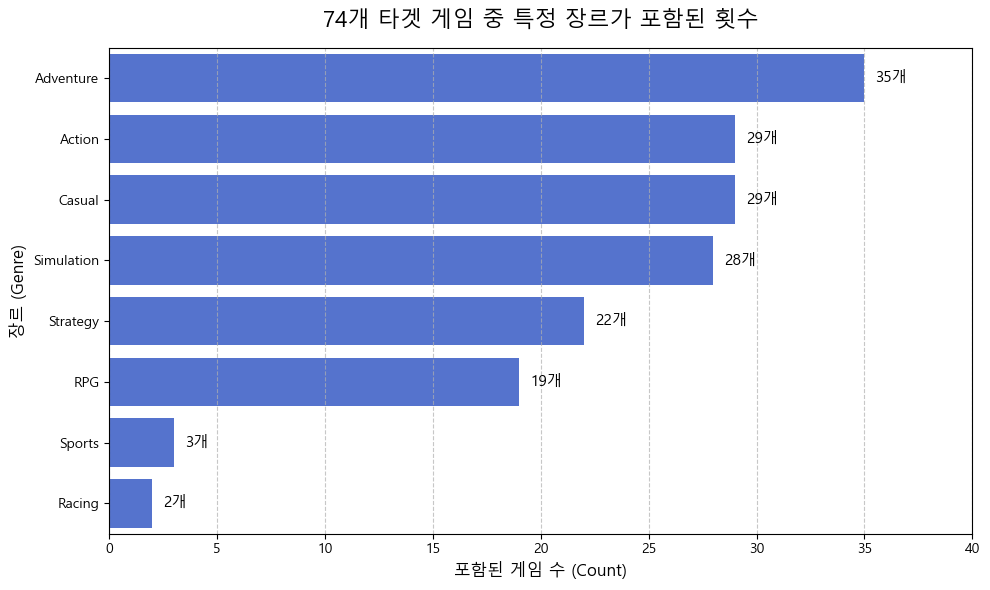

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 폰트 설정 (한글 깨짐 방지용)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 및 74개 타겟 필터링
df_sample = pd.read_csv('steam_stratified_sample.csv')
df_sample.columns = df_sample.columns.str.strip()

target_strata = ['large_high', 'mid_high', 'small_high']
df_target = df_sample[df_sample['stratum'].isin(target_strata)].copy()

total_games = len(df_target)
print(f"✅ 전체 분석 대상 게임 수: {total_games}개\n")

# 2. 8대 메인 장르 키워드 정의 (영문)
target_genres = {
    'Action': 'Action',
    'Adventure': 'Adventure',
    'Casual': 'Casual',
    'Simulation': 'Simulation',
    'RPG': 'RPG',
    'Strategy': 'Strategy',
    'Sports': 'Sports',
    'Racing': 'Racing'
}

# 3. 각 장르별 포함 횟수(중복 허용) 카운트
genre_counts = []
for genre_name, keyword in target_genres.items():
    # 해당 장르 키워드를 포함(contains)하는 게임의 수를 합산
    count = df_target['genres'].str.contains(keyword, case=False, na=False).sum()
    genre_counts.append({'Genre': genre_name, 'Count': count})

# 데이터프레임으로 변환 후 카운트 기준 내림차순 정렬
df_counts = pd.DataFrame(genre_counts).sort_values(by='Count', ascending=False)
# 74개 중 몇 퍼센트의 게임이 해당 장르를 달고 있는지 계산
df_counts['Percentage(%)'] = (df_counts['Count'] / total_games * 100).round(1)

# 4. 텍스트 결과 출력 (보고서 복사 붙여넣기용)
print("="*45)
print(" 📊 8대 핵심 장르별 포함 횟수 (중복 포함) ")
print("="*45)
print(df_counts.to_string(index=False))
print("="*45)

# 5. 시각화 (가로형 막대 그래프)
plt.figure(figsize=(10, 6))
# 색상을 통일감 있게 하나로 지정 (단정하게)
ax = sns.barplot(data=df_counts, x='Count', y='Genre', color='royalblue')

# 막대 끝에 숫자 달아주기
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height()/2, f'{int(width)}개', 
             ha='left', va='center', fontsize=11)

plt.title("74개 타겟 게임 중 특정 장르가 포함된 횟수", fontsize=16, pad=15)
plt.xlabel("포함된 게임 수 (Count)", fontsize=12)
plt.ylabel("장르 (Genre)", fontsize=12)
plt.xlim(0, df_counts['Count'].max() + 5) # 글자가 잘리지 않게 오른쪽 여백 확보
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()